# 🌾 MODULE KHỬ NHIỄU & TÁCH HẠT LÚA CHÍNH (GRAIN CROP CLEANER)
**Mục đích**:
- Khử bỏ toàn bộ các mảnh vụn, góc cạnh của hạt lúa lân cận bị dính vào trong ảnh crop.
- Giữ lại duy nhất **1 đối tượng hạt lúa chính** ở trung tâm và có diện tích lớn nhất.
- Đặt toàn bộ vùng ngoài thành **nền trong suốt (Alpha = 0, RGB = [0, 0, 0])**.
- Hỗ trợ: **Test trên 1 ảnh đơn lẻ** hoặc **Quét tự động toàn bộ Dataset** chứa thư mục `OUTPUT_CROPPED_GRAINS` và lưu kết quả vào thư mục cùng cấp `OUTPUT_CLEANED_GRAINS`.


In [5]:
# Bước 1: Kết nối Google Drive & Import Module
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import importlib
from pathlib import Path

# Cấu hình đường dẫn dự án
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES"
except Exception:
    BASE_PATH = r"d:\GG_1\NGHIÊN CỨU KHOA HỌC\GROUP_MEMBERS\NGUYEN MINH TRI\MAIN_SOURCES"

code_dir = os.path.join(BASE_PATH, "CODE")
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

# Tự động reload module nếu đã import từ trước
if 'modules.grain_crop_cleaner' in sys.modules:
    importlib.reload(sys.modules['modules.grain_crop_cleaner'])

# Import module GrainCropCleaner
from modules.grain_crop_cleaner import (
    GrainCropCleaner,
    clean_single_grain_crop,
    clean_dataset_cropped_grains,
    imread_unicode,
    imwrite_unicode
)

print("✅ Import Module GrainCropCleaner thành công (Đã cập nhật tính năng mới)!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Import Module GrainCropCleaner thành công (Đã cập nhật tính năng mới)!


📸 Đang test trên ảnh: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DETECTED_OBJECTS/DATA2/OUTPUT_CROPPED_GRAINS/test1_grain_0010.png


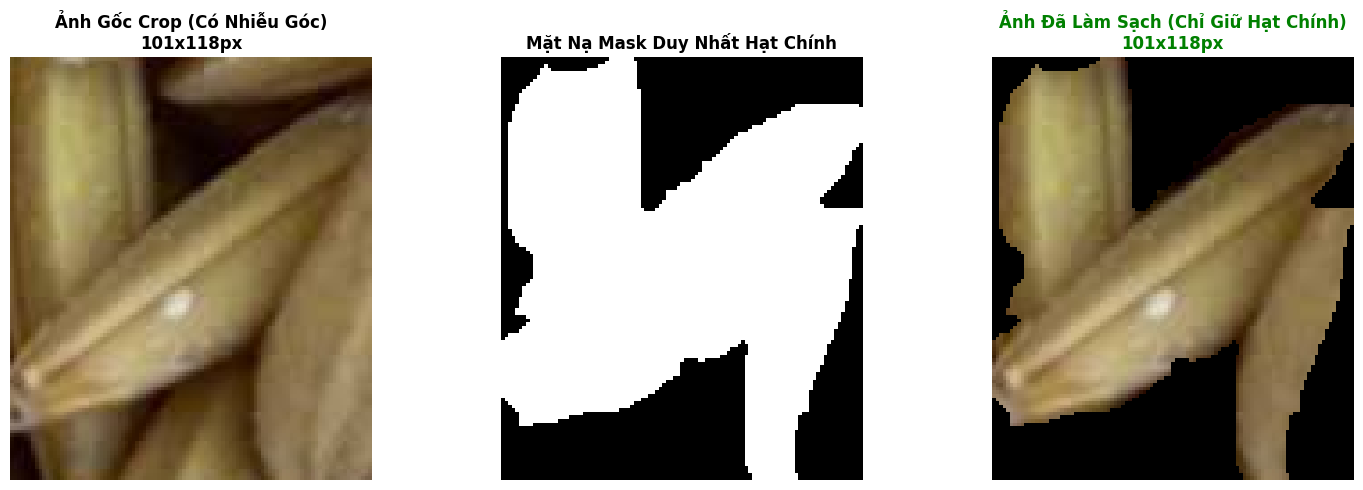

In [ ]:
# Bước 2: TEST TRÊN 1 ẢNH ĐƠN LẺ (So sánh Trực quan Trước và Sau khi Khử Nhiễu)
# Đường dẫn ảnh crop cần test thử
sample_img_path = os.path.join(BASE_PATH, "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DETECTED_OBJECTS/DATA2/OUTPUT_CROPPED_GRAINS/test1_grain_0010.png")

# Nếu không tìm thấy ảnh mẫu trên, tự động tìm 1 ảnh bất kỳ
if not os.path.exists(sample_img_path):
    for p in Path(BASE_PATH).rglob("*.png"):
        if "crop" in str(p).lower():
            sample_img_path = str(p)
            break

print(f"📸 Đang test trên ảnh: {sample_img_path}")

# 1. Đọc ảnh gốc
raw_img = imread_unicode(sample_img_path)

# 2. Gọi hàm làm sạch khử nhiễu
clean_img = clean_single_grain_crop(
    image_input=raw_img,
    min_area=20,
    centrality_weight=2.5,
    fill_holes=True,
    re_crop=False  # Đổi thành True nếu muốn crop sát viền hạt lúa
)

# 3. Hiển thị so sánh Before vs After
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ảnh gốc (3 kênh màu)
axes[0].imshow(cv2.cvtColor(raw_img[:, :, :3], cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Ảnh Gốc Crop (Có Nhiễu Góc)\n{raw_img.shape[1]}x{raw_img.shape[0]}px", fontweight="bold")
axes[0].axis("off")

# Mặt nạ Alpha gốc vs sau làm sạch
raw_alpha = raw_img[:, :, 3] if raw_img.shape[2] == 4 else np.zeros(raw_img.shape[:2])
clean_alpha = clean_img[:, :, 3]
axes[1].imshow(clean_alpha, cmap="gray")
axes[1].set_title("Mặt Nạ Mask Duy Nhất Hạt Chính", fontweight="bold")
axes[1].axis("off")

# Ảnh đã làm sạch (Nền đen/trong suốt)
axes[2].imshow(cv2.cvtColor(clean_img[:, :, :3], cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Ảnh Đã Làm Sạch (Chỉ Giữ Hạt Chính)\n{clean_img.shape[1]}x{clean_img.shape[0]}px", fontweight="bold", color="green")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Bước 3: KIỂM TRA VÀ ĐỐI SOÁT SỐ LƯỢNG ẢNH ĐẦU VÀO (INPUT COUNT & AUDIT)
# Cell này giúp bạn kiểm tra chính xác số lượng ảnh crop đầu vào (Cropped Grains)
# và so sánh đối chiếu với thư mục đã làm sạch (Cleaned Grains) nếu có.

from collections import defaultdict
from pathlib import Path

# Cấu hình thư mục muốn kiểm tra (mặc định kiểm tra DATA3, hoặc DETECTED_OBJECTS để quét toàn bộ)
CHECK_PATH = os.path.join(BASE_PATH, "DETECTED_OBJECTS/DATA2")
valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

check_p = Path(CHECK_PATH)
cropped_folders = []
for p in check_p.rglob("*"):
    if p.is_dir() and p.name.lower() == "output_cropped_grains":
        cropped_folders.append(p)
if not cropped_folders and check_p.name.lower() == "output_cropped_grains":
    cropped_folders.append(check_p)

print("=" * 75)
print("📊 BÁO CÁO KIỂM TRA SỐ LƯỢNG ẢNH ĐẦU VÀO (CROPPED GRAINS)")
print("=" * 75)
print(f"📂 Thư mục quét: {CHECK_PATH}")
print(f"🔎 Tìm thấy {len(cropped_folders)} thư mục OUTPUT_CROPPED_GRAINS\n")

total_all_cropped = 0
total_all_cleaned = 0

for idx, c_dir in enumerate(cropped_folders, 1):
    clean_dir = c_dir.parent / "OUTPUT_CLEANED_GRAINS"

    # Đếm ảnh trong cropped folder
    cropped_files = [f for f in c_dir.rglob("*") if f.is_file() and f.suffix.lower() in valid_exts and "output_cleaned_grains" not in str(f).lower()]
    cleaned_files = [f for f in clean_dir.rglob("*") if f.is_file() and f.suffix.lower() in valid_exts] if clean_dir.exists() else []

    total_all_cropped += len(cropped_files)
    total_all_cleaned += len(cleaned_files)

    # Gom nhóm theo tiền tố ảnh (ví dụ: test01, test02,...)
    prefix_counts = defaultdict(lambda: {"cropped": 0, "cleaned": 0})
    for f in cropped_files:
        prefix = f.stem.split("_")[0]
        prefix_counts[prefix]["cropped"] += 1
    for f in cleaned_files:
        prefix = f.stem.split("_")[0]
        prefix_counts[prefix]["cleaned"] += 1

    print(f"[{idx}/{len(cropped_folders)}] 📁 Folder: {c_dir}")
    print(f"   • Tổng số ảnh Crop đầu vào : {len(cropped_files):,} ảnh")
    print(f"   • Đã Clean & Lưu           : {len(cleaned_files):,} ảnh")

    diff = len(cropped_files) - len(cleaned_files)
    if diff > 0:
        print(f"   ⚠️ CẢNH BÁO: Còn thiếu {diff:,} ảnh chưa được làm sạch! (Hãy chạy Bước 4)")
    elif diff == 0 and len(cropped_files) > 0:
        print(f"   ✅ ĐỒNG BỘ 100%: Toàn bộ {len(cropped_files):,} ảnh đã được làm sạch đầy đủ.")

    # Hiển thị chi tiết theo từng mẫu
    print("\n   📋 Thống kê chi tiết theo từng ảnh mẫu:")
    print("   " + "-" * 55)
    header_sample = 'Mẫu ảnh'
    header_crop = 'Số hạt Crop'
    header_clean = 'Số hạt Clean'
    header_status = 'Trạng thái'
    print(f"   {header_sample:<15} | {header_crop:<15} | {header_clean:<15} | {header_status}")
    print("   " + "-" * 55)

    for pfx in sorted(prefix_counts.keys()):
        cr = prefix_counts[pfx]["cropped"]
        cl = prefix_counts[pfx]["cleaned"]
        st = "✅ Đủ" if cr == cl else f"⚠️ Thiếu {cr - cl}"
        print(f"   {pfx:<15} | {cr:<15} | {cl:<15} | {st}")
    print("   " + "-" * 55 + "\n")

print("=" * 75)
print(f"🎯 TỔNG KẾT TOÀN BỘ: {total_all_cropped:,} ảnh Crop đầu vào | {total_all_cleaned:,} ảnh Clean đã lưu")
print("=" * 75)


📊 BÁO CÁO KIỂM TRA SỐ LƯỢNG ẢNH ĐẦU VÀO (CROPPED GRAINS)
📂 Thư mục quét: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DETECTED_OBJECTS/DATA2
🔎 Tìm thấy 1 thư mục OUTPUT_CROPPED_GRAINS

[1/1] 📁 Folder: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DETECTED_OBJECTS/DATA2/OUTPUT_CROPPED_GRAINS
   • Tổng số ảnh Crop đầu vào : 7,264 ảnh
   • Đã Clean & Lưu           : 0 ảnh
   ⚠️ CẢNH BÁO: Còn thiếu 7,264 ảnh chưa được làm sạch! (Hãy chạy Bước 4)

   📋 Thống kê chi tiết theo từng ảnh mẫu:
   -------------------------------------------------------
   Mẫu ảnh         | Số hạt Crop     | Số hạt Clean    | Trạng thái
   -------------------------------------------------------
   test1           | 121             | 0               | ⚠️ Thiếu 121
   test10          | 721             | 0               | ⚠️ Thiếu 721
   test11          | 598             | 0               | ⚠️ Thiếu 598
   test12          | 587          

In [ ]:
# Bước 4: QUÉT VÀ LÀM SẠCH TỰ ĐỘNG TOÀN BỘ DATASET (BATCH PROCESSING)
# =============================================================================
# 🛠️ BẢNG CẤU HÌNH TOÀN BỘ THAM SỐ (TÙY CHỈNH DỄ DÀNG TẠI ĐÂY)
# =============================================================================
DATASET_ROOT_PATH = os.path.join(BASE_PATH, "DETECTED_OBJECTS/DATA3")
TARGET_SUBFOLDER  = "OUTPUT_CROPPED_GRAINS"   # Thư mục nguồn chứa ảnh crop
OUTPUT_SUBFOLDER  = "OUTPUT_CLEANED_GRAINS"   # Thư mục đích lưu ảnh sạch cùng cấp

# Tùy chọn tăng tốc và hiển thị
SKIP_EXISTING     = True   # ⚡ True: Bỏ qua ảnh đã làm sạch (chạy siêu nhanh) | False: Ghi đè
SHOW_PROGRESS     = True   # ⏳ Hiển thị thanh tiến trình % thời gian thực

# Tham số bẻ cầu nối dính và loại bỏ dị vật
SEVER_BRIDGES     = True   # True: Bật bẻ cầu nối dính (Watershed)
OPEN_KSIZE        = 3      # Độ dày cầu nối pixel (3: cầu dính 1-3px | 5: cầu dính to 3-5px)
MIN_NECK_RATIO    = 0.15   # Tỷ lệ eo dính so với thân hạt (0.15 = 15% bề dày hạt)
MIN_AREA          = 20     # Diện tích tối thiểu (pixel) loại bỏ rác nhỏ
CENTRALITY_WEIGHT = 2.5    # Trọng số ưu tiên hạt ở giữa tâm ảnh
FILL_HOLES        = True   # Lấp kín lỗ rỗng bên trong thân hạt

# Tùy chọn cắt gọn viền
RE_CROP           = False  # False: Giữ nguyên size gốc | True: Cắt gọn ôm sát hạt
PADDING           = 2      # Khoảng đệm viền nếu bật RE_CROP
# =============================================================================

stats = clean_dataset_cropped_grains(
    root_path=DATASET_ROOT_PATH,
    target_subfolder=TARGET_SUBFOLDER,
    output_subfolder=OUTPUT_SUBFOLDER,
    min_area=MIN_AREA,
    centrality_weight=CENTRALITY_WEIGHT,
    fill_holes=FILL_HOLES,
    sever_bridges=SEVER_BRIDGES,
    open_ksize=OPEN_KSIZE,
    min_neck_ratio=MIN_NECK_RATIO,
    re_crop=RE_CROP,
    padding=PADDING,
    skip_existing=SKIP_EXISTING,
    show_progress=SHOW_PROGRESS,
    verbose=True
)


🧹 MODULE KHỬ NHIỄU, BẺ EO DÍNH & LÀM SẠCH ẢNH HẠT LÚA CROP
📂 Thư mục gốc           : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DETECTED_OBJECTS/DATA2
🎯 Thư mục mục tiêu      : OUTPUT_CROPPED_GRAINS
📁 Thư mục xuất cùng cấp : OUTPUT_CLEANED_GRAINS
🔎 Tìm thấy              : 1 thư mục cần xử lý.
✂️ Cơ chế bẻ cầu nối eo : BẬT (Sever Bridges Active)
⚡ Bỏ qua ảnh đã có      : TẮT (Ghi đè tất cả)

[1/1] 📁 Đang xử lý: OUTPUT_CROPPED_GRAINS/OUTPUT_CROPPED_GRAINS
   ↳ Tổng số ảnh tìm thấy: 7,264 ảnh


   ⏳ Tiến trình [1/1]:   0%|                                        | 0/7264 [00:00<?, ?ảnh/s]

KeyboardInterrupt: 

In [ ]:
# Bước 5: HIỂN THỊ LƯỚI ẢNH MẪU (GALLERY SO SÁNH TRƯỚC VÀ SAU KHI LÀM SẠCH)
sample_cleaned_dir = os.path.join(BASE_PATH, "DETECTED_OBJECTS/DATA1/OUTPUT_CLEANED_GRAINS/hat_nguyen")
raw_dir = os.path.join(BASE_PATH, "DETECTED_OBJECTS/DATA1/OUTPUT_CROPPED_GRAINS/hat_nguyen")

if os.path.exists(sample_cleaned_dir):
    clean_files = [f for f in os.listdir(sample_cleaned_dir) if f.endswith('.png')][:8]

    plt.figure(figsize=(16, 8))
    for i, fname in enumerate(clean_files):
        # Đọc ảnh gốc
        img_before = imread_unicode(os.path.join(raw_dir, fname))
        # Đọc ảnh đã clean
        img_after = imread_unicode(os.path.join(sample_cleaned_dir, fname))

        # Cột Trước
        plt.subplot(4, 4, i * 2 + 1)
        plt.imshow(cv2.cvtColor(img_before[:, :, :3], cv2.COLOR_BGR2RGB))
        plt.title(f"Gốc #{i+1}", fontsize=9)
        plt.axis("off")

        # Cột Sau
        plt.subplot(4, 4, i * 2 + 2)
        plt.imshow(cv2.cvtColor(img_after[:, :, :3], cv2.COLOR_BGR2RGB))
        plt.title(f"Clean #{i+1} ✅", fontsize=9, color="green")
        plt.axis("off")

    plt.suptitle("So Sánh Các Mẫu Hạt: Trước khi làm sạch (Có rác góc) vs Sau khi làm sạch (Chỉ 1 hạt)", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("❌ Hãy chạy Bước 3 trước để tạo thư mục OUTPUT_CLEANED_GRAINS.")
